In [2]:
!pip install -q boltz biopython matplotlib py3Dmol pyyaml

import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
import os
import yaml

os.makedirs("boltz_input", exist_ok=True)
os.makedirs("boltz_output", exist_ok=True)

# Drosophila Hedgehog N-terminal domain (signaling fragment)
hedgehog_seq = ("CGPGRGFVGIAQHGYLLAHKDTCSGSLFNENTSIREEL"
                "QHLAPLGKSLKFRADVRPYSGHMKAILTHQHYEGFTPH"
                "TAHFQGSMSASPHYNGFELPSLAKADTSYYYGEGTTRIS"
                "EHAVEELMRSDRGKFTPDLAKCSAQGCCFPRT")

# Write as FASTA for simple prediction
with open("boltz_input/hedgehog.fasta", "w") as f:
    f.write(">Drosophila_Hedgehog_Nterm\n")
    f.write(hedgehog_seq + "\n")

# Also write YAML for protein
# Hedgehog proteins are known to coordinate Zn2+ ions
boltz_yaml = {
    "version": 1,
    "sequences": [
        {
            "protein": {
                "id": "A",
                "sequence": hedgehog_seq
            }
        }
    ]
}

with open("boltz_input/hedgehog.yaml", "w") as f:
    yaml.dump(boltz_yaml, f, default_flow_style=False)

print("=" * 60)
print("BOLTZ-2 INPUT PREPARED")
print("=" * 60)
print(f"  Protein: Drosophila Hedgehog N-terminal domain")
print(f"  Length: {len(hedgehog_seq)} aa")
print(f"  Files: hedgehog.fasta, hedgehog.yaml")

BOLTZ-2 INPUT PREPARED
  Protein: Drosophila Hedgehog N-terminal domain
  Length: 147 aa
  Files: hedgehog.fasta, hedgehog.yaml


In [4]:
import time

print("=" * 60)
print("RUNNING BOLTZ-2 STRUCTURE PREDICTION")
print("=" * 60)
print("This may take 2-5 minutes on T4 GPU...\n")

start = time.time()

!boltz predict boltz_input/ --out_dir boltz_output/ --use_msa_server --recycling_steps 3

elapsed = time.time() - start
print(f"\n✓ Prediction complete in {elapsed/60:.1f} minutes")


RUNNING BOLTZ-2 STRUCTURE PREDICTION
This may take 2-5 minutes on T4 GPU...

MSA server enabled: https://api.colabfold.com
MSA server authentication: no credentials provided
Extracting the CCD data to /root/.boltz/mols. This may take a bit of time. You may change the cache directory with the --cache flag.
Checking input data.
Processing 2 inputs with 2 threads.
  0% 0/2 [00:00<?, ?it/s]Generating MSA for boltz_input/hedgehog.yaml with 1 protein entities.
Calling MSA server for target hedgehog with 1 sequences
MSA server URL: https://api.colabfold.com
MSA pairing strategy: greedy
No authentication provided for MSA server
SUBMIT:   0% 0/150 [00:00<?, ?it/s]Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/boltz/main.py", line 549, in process_input
    target = parse_fasta(path, ccd, mol_dir, boltz2)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/boltz/data/parse/fasta.py", line 56, in parse_fasta
    r

In [5]:
import py3Dmol
import glob

print("=" * 60)
print("3D VISUALIZATION")
print("=" * 60)

# Find output structure
cif_files = sorted(glob.glob("boltz_output/**/*.cif", recursive=True))
pdb_files = sorted(glob.glob("boltz_output/**/*.pdb", recursive=True))
struct_files = cif_files + pdb_files

if struct_files:
    print(f"Found {len(struct_files)} structure(s)")
    struct_file = struct_files[0]

    with open(struct_file) as f:
        struct_data = f.read()

    fmt = "cif" if struct_file.endswith(".cif") else "pdb"

    view = py3Dmol.view(width=800, height=600)
    view.addModel(struct_data, fmt)
    view.setStyle({'cartoon': {'color': 'spectrum'}})
    view.addSurface(py3Dmol.VDW, {'opacity': 0.2, 'color': 'white'})
    view.zoomTo()
    view.show()
else:
    print("No output structures found — check boltz_output/ directory")
    !find boltz_output/ -type f

3D VISUALIZATION
Found 1 structure(s)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Confidence scores: {
  "confidence_score": 0.3193971514701843,
  "ptm": 0.2091815173625946,
  "iptm": 0.0,
  "ligand_iptm": 0.0,
  "protein_iptm": 0.0,
  "complex_plddt": 0.34695103764533997,
  "complex_iplddt": 0.34695103764533997,
  "complex_pde": 3.8060150146484375,
  "complex_ipde": 0.0,
  "chains_ptm": {
    "0": 0.2091815173625946
  },
  "pair_chains_iptm": {
    "0": {
      "0": 0.2091815173625946
    }
  }
}


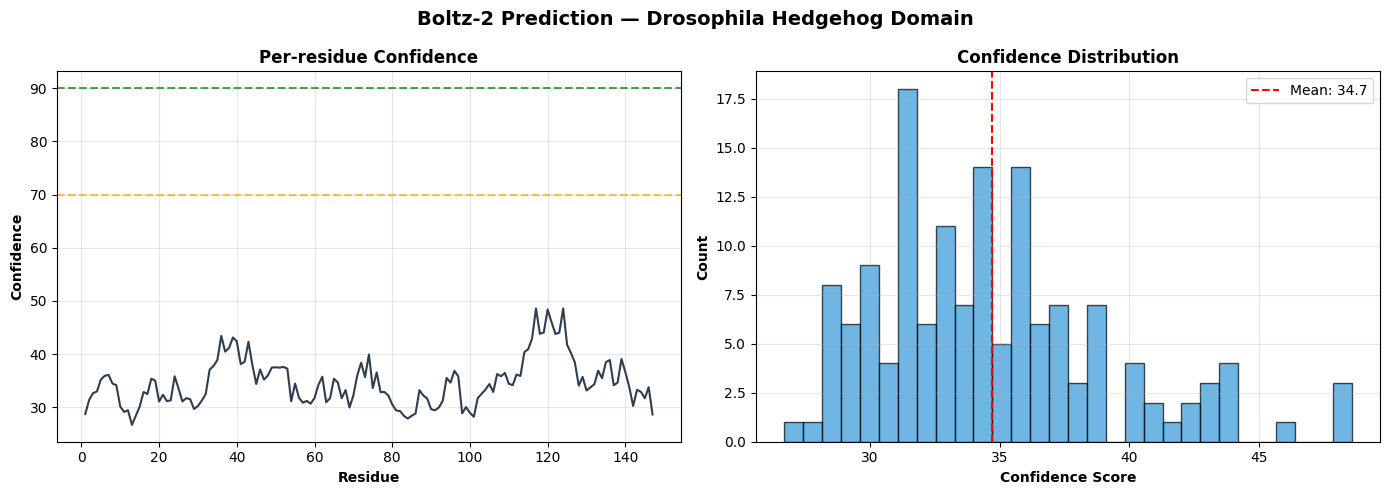

✓ Figure saved: boltz_analysis.png


In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Look for confidence scores
json_files = sorted(glob.glob("boltz_output/**/*confidence*.json", recursive=True))
json_files += sorted(glob.glob("boltz_output/**/*scores*.json", recursive=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Boltz-2 Prediction — Drosophila Hedgehog Domain",
             fontweight='bold', fontsize=14)

if json_files:
    with open(json_files[0]) as f:
        scores = json.load(f)
    print("Confidence scores:", json.dumps(scores, indent=2)[:500])

# If we have a PDB/CIF, extract B-factors as confidence
if struct_files:
    from Bio.PDB import PDBParser, MMCIFParser

    if struct_file.endswith(".cif"):
        p = MMCIFParser(QUIET=True)
    else:
        p = PDBParser(QUIET=True)

    structure = p.get_structure("boltz", struct_file)

    # Extract per-residue confidence from B-factors
    confidence = []
    for model in structure:
        for chain in model:
            for residue in chain:
                if residue.id[0] == ' ':
                    for atom in residue:
                        if atom.name == 'CA':
                            confidence.append(atom.get_bfactor())
                            break

    if confidence:
        confidence = np.array(confidence)

        # Plot confidence per residue
        axes[0].plot(range(1, len(confidence)+1), confidence,
                    color='#2c3e50', linewidth=1.5)
        axes[0].axhline(y=70, color='orange', linestyle='--', alpha=0.7)
        axes[0].axhline(y=90, color='green', linestyle='--', alpha=0.7)
        axes[0].set_xlabel("Residue", fontweight='bold')
        axes[0].set_ylabel("Confidence", fontweight='bold')
        axes[0].set_title("Per-residue Confidence", fontweight='bold')
        axes[0].grid(True, alpha=0.3)

        # Confidence distribution
        axes[1].hist(confidence, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
        axes[1].axvline(x=np.mean(confidence), color='red', linestyle='--',
                       label=f'Mean: {np.mean(confidence):.1f}')
        axes[1].set_xlabel("Confidence Score", fontweight='bold')
        axes[1].set_ylabel("Count", fontweight='bold')
        axes[1].set_title("Confidence Distribution", fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("boltz_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure saved: boltz_analysis.png")


In [7]:

!cp boltz_analysis.png boltz_output/
!zip -r -q boltz_results.zip boltz_output/

from google.colab import files
files.download("boltz_results.zip")
print("✓ Download complete")






<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download complete

Move to: stowers-gpu-tools/boltz/results/sample_output/
